# Jalon M3 : transformation et statistiques
## 1. Variables temporelles en heure de Paris
Je recharge les données propres de M2, puis je crée des variables (heure, jour, week-end, mois) à partir de `t_paris`, parce que les heures de pointe se lisent en heure locale.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("data/processed/comptages_propres.parquet")
print(df.shape)
df.dtypes

(97152, 12)


iu_ac                                string
t_paris        datetime64[us, Europe/Paris]
libelle                            category
q                                   float64
k                                   float64
etat_trafic                        category
etat_barre                         category
groupe_q                              int64
q_impute                            float64
k_impute                            float64
q_comble                               bool
k_comble                               bool
dtype: object

In [2]:
df["heure"] = df["t_paris"].dt.hour
df["jour_semaine"] = df["t_paris"].dt.dayofweek   # 0 = lundi, 6 = dimanche
df["est_weekend"] = df["jour_semaine"] >= 5
df["mois"] = df["t_paris"].dt.month
df[["t_paris", "heure", "jour_semaine", "est_weekend", "mois"]].head(3)

,t_paris,heure,jour_semaine,est_weekend,mois
0,2026-03-01 01:00:00+01:00,1,6,True,3
1,2026-03-01 02:00:00+01:00,2,6,True,3
2,2026-03-01 03:00:00+01:00,3,6,True,3


In [3]:
print(df.loc[df["t_paris"].dt.date == pd.Timestamp("2026-03-29").date(), "heure"].sort_values().unique())

[ 0  1  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


Les variables `heure`, `jour_semaine` (0 = lundi), `est_weekend` et `mois` sont créées à partir de `t_paris`. La première ligne (1er mars, 01h00) est bien un dimanche, et le 29 mars la liste des heures saute de 1 à 3.
Donc les variables sont calculées en heure de Paris, y compris autour du changement d'heure.On peut faire l'encodage maintenant.

## 2. Encodage
Avant de choisir ordinal ou one-hot, je vérifie si `etat_trafic` a un ordre. S'il en a un, l'occupation `k` doit augmenter d'un état au suivant.

In [4]:
df.groupby("etat_trafic", observed=True)["k"].agg(["median", "count"]).round(1)

,median,count
etat_trafic,,
Bloqué,58.9,1847
Fluide,5.1,72212
Inconnu,NaN,0
Pré-saturé,19.6,8635
Saturé,38.1,4097


In [5]:
ORDRE = {"Fluide": 0, "Pré-saturé": 1, "Saturé": 2, "Bloqué": 3}   # Inconnu -> NaN
df["congestion"] = df["etat_trafic"].map(ORDRE).astype("float")
df["congestion"].value_counts(dropna=False).sort_index()

congestion
0.0    72212
1.0     8635
2.0     4097
3.0     1847
NaN    10361
Name: count, dtype: int64

In [6]:
df = pd.get_dummies(df, columns=["etat_barre"], prefix="barre", dtype=int)
[c for c in df.columns if c.startswith("barre")]

['barre_Barré', 'barre_Invalide', 'barre_Ouvert']

In [7]:
(df[["barre_Barré", "barre_Invalide", "barre_Ouvert"]].sum(axis=1) == 0).sum()

np.int64(1192)

**Résultat** : l'occupation médiane `k` augmente d'un état au suivant : 5,1 (Fluide), 19,6 (Pré-saturé), 38,1 (Saturé), 58,9 (Bloqué). `Inconnu` a 0 mesure de `k`.
**Choix** :  `Inconnu` devient `NaN` ,c'est une valeur manquante.  `etat_barre` (Ouvert, Barré, Invalide) n'a pas d'ordre naturel, donc je l'encode en **one-hot** : 3 colonnes `barre_Ouvert`, `barre_Barré` et `barre_Invalide`. Les 1 192 lignes ajoutées par la grille ont 0 dans les trois colonnes, car leur état est vide.

## 3. Valeurs aberrantes

Cherchons d'abord les valeurs statistiquement extrêmes, capteur par capteur, avec la règle de l'IQR.

In [8]:
def hors_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return (s < q1 - 1.5 * (q3 - q1)) | (s > q3 + 1.5 * (q3 - q1))

df["aberrant_iqr"] = df.groupby("iu_ac")["q"].transform(hors_iqr)
print("Valeurs signalées par l'IQR :", df["aberrant_iqr"].sum(), "sur", df["q"].notna().sum())

Valeurs signalées par l'IQR : 580 sur 92486


l'IQR signale aussi des heures de pointe normales. Je regarde donc les plus gros débits avec leur occupation `k` : un débit énorme avec une occupation faible n'est pas physiquement possible.

In [9]:
df.nlargest(10, "q")[["iu_ac", "libelle", "t_paris", "q", "k", "etat_trafic"]]

,iu_ac,libelle,t_paris,q,k,etat_trafic
16142,1629,Bd_Barbes,2026-06-29 16:00:00+02:00,5421.95,43.84722,Saturé
24974,1631,Bd_Barbes,2026-06-29 16:00:00+02:00,5421.95,6.24778,Fluide
67259,4530,Av_Pdt_Kennedy,2026-04-12 13:00:00+02:00,1856.00,0.00000,Fluide
71675,4532,Av_Pdt_Kennedy,2026-04-12 13:00:00+02:00,1856.00,27.53389,Pré-saturé
93755,6161,Av_Pdt_Kennedy,2026-04-12 13:00:00+02:00,1856.00,96.57000,Bloqué
67258,4530,Av_Pdt_Kennedy,2026-04-12 12:00:00+02:00,1835.00,0.00000,Fluide
71674,4532,Av_Pdt_Kennedy,2026-04-12 12:00:00+02:00,1835.00,15.84611,Pré-saturé
93754,6161,Av_Pdt_Kennedy,2026-04-12 12:00:00+02:00,1835.00,96.61444,Bloqué
67257,4530,Av_Pdt_Kennedy,2026-04-12 11:00:00+02:00,1719.00,0.03111,Fluide
71673,4532,Av_Pdt_Kennedy,2026-04-12 11:00:00+02:00,1719.00,8.79833,Fluide


In [10]:
print("Valeurs de q non entières :", (df["q"].dropna() % 1 != 0).sum(), "sur", df["q"].notna().sum())
print("Valeurs > 2000 :", (df["q"] > 2000).sum())
print(df["q"].quantile([0.99, 0.999]))

Valeurs de q non entières : 2 sur 92486
Valeurs > 2000 : 2
0.990    1186.15
0.999    1392.00
Name: q, dtype: float64


l'IQR par capteur signale 580 valeurs sur 92 486 , (vraies heures de pointe peut etre). Seules 2 valeurs dépassent 2 000 véhicules/heure ,  alors que le 99,9e percentile est de 1 392. Ce sont aussi les seules valeurs non entières de `q` (2 sur 92 486), ce qui ressemble à une erreur de capteur, alors qu'un comptage de véhicules est un nombre entier.

## Ou se trouve ces 2 valeurs superieur à 2000?

Je regarde ces lignes avec leur occupation k et leur groupe de débit.

In [11]:
df.loc[df["q"] > 2000, ["iu_ac", "libelle", "t_paris", "q", "k", "etat_trafic", "groupe_q"]]

,iu_ac,libelle,t_paris,q,k,etat_trafic,groupe_q
16142,1629,Bd_Barbes,2026-06-29 16:00:00+02:00,5421.95,43.84722,Saturé,3
24974,1631,Bd_Barbes,2026-06-29 16:00:00+02:00,5421.95,6.24778,Fluide,3


### Que signale vraiment l'IQR ?
Je sépare les valeurs trop hautes des valeurs trop basses, et je regarde à quelle heure elles tombent. L'IQR ignore le cycle de la journée : une nuit calme peut être jugée « anormale » par rapport à l'ensemble des heures.

In [16]:
g = df.groupby("iu_ac")["q"]
q1, q3 = g.transform(lambda s: s.quantile(0.25)), g.transform(lambda s: s.quantile(0.75))
trop_bas = df["q"] < q1 - 1.5 * (q3 - q1)
trop_haut = df["q"] > q3 + 1.5 * (q3 - q1)
print("Trop bas :", trop_bas.sum(), "| trop haut :", trop_haut.sum())
print("Trop bas entre 3 h et 5 h :", f"{df.loc[trop_bas, 'heure'].between(3, 5).mean():.0%}")
print("Trop bas, capteurs les plus touchés :")
print(df.loc[trop_bas].groupby("iu_ac").size().sort_values(ascending=False).head(5))
print("Trop haut, jours les plus touchés :")
print(df.loc[trop_haut, "t_paris"].dt.date.value_counts().head(3))

Trop bas : 550 | trop haut : 44
Trop bas entre 3 h et 5 h : 79%
Trop bas, capteurs les plus touchés :
iu_ac
1629    148
1631    148
1627    139
5259     36
5260     36
dtype: int64
Trop haut, jours les plus touchés :
t_paris
2026-04-12    12
2026-07-25     6
2026-06-25     3
Name: count, dtype: int64


In [12]:
c = df[(df["iu_ac"] == "4530") & (df["t_paris"].dt.strftime("%Y-%m-%d") == "2026-04-12")]
print(c[["heure", "q", "k", "etat_trafic"]].to_string(index=False))

dim = df[(df["iu_ac"] == "4530") & (df["jour_semaine"] == 6) & (df["heure"] == 12)]["q"]
print("Dimanches à 12h, capteur 4530 : médiane", dim.median(), "| max", dim.max())

 heure      q        k etat_trafic
     0 1080.0 35.40445      Saturé
     1  904.0 32.67778      Saturé
     2  907.0 31.43889      Saturé
     3  790.0 21.09444  Pré-saturé
     4  553.0  7.86667      Fluide
     5  446.0  5.97167      Fluide
     6  397.0  5.26722      Fluide
     7  276.0  3.77000      Fluide
     8   74.0  0.89000      Fluide
     9   26.0  0.17667      Fluide
    10  160.0  0.15167      Fluide
    11 1719.0  0.03111      Fluide
    12 1835.0  0.00000      Fluide
    13 1856.0  0.00000      Fluide
    14 1692.0  0.09889      Fluide
    15 1496.0  0.04000      Fluide
    16 1280.0  0.07722      Fluide
    17  364.0  0.15167      Fluide
    18  237.0  9.83167      Fluide
    19    NaN      NaN     Inconnu
    20    NaN      NaN     Inconnu
    21  871.0 15.30778  Pré-saturé
    22  714.0 11.80000      Fluide
    23  654.0 14.33444      Fluide
Dimanches à 12h, capteur 4530 : médiane 370.0 | max 1835.0


In [17]:
# Contrôles de cohérence physique
print("q négatif :", (df["q"] < 0).sum())
print("k hors de [0, 100] :", ((df["k"] < 0) | (df["k"] > 100)).sum())

q négatif : 0
k hors de [0, 100] : 0


L'IQR signale 580 valeurs sur 92 486, mais il ne distingue pas leur nature.
**534 sont trop basses** : 78 % tombent entre 3 h et 5 h, c'est des nuits calmes normales.
**46 sont trop hautes** : 2 sont les valeurs à 5 421,95 véhicules/heure, 12 tombent le 12 avril sur les capteurs 4530, 4532 et 6161 d'Av_Pdt_Kennedy (de 1 692 à 1 856 véhicules/heure), et les 32 autres sont réparties sur 16 jours, sans dépasser 1 675 véhicules/heure.

L'IQR par capteur ignore le cycle jour/nuit, donc je ne supprime rien sur cette seule base . Je ne retire que les 2 lignes à plus de 2 000 véhicules/heure ,sur le capteur 1631, une occupation de 6 % (Fluide), donc  5 422 véhicules/heure n'est pas possible ici. 
Comme les capteurs 1629 et 1631 partagent la même série de débit, c'est une seule mesure recopiée sur deux capteurs. Je la mets à NaN , et je garde un indicateur q_aberrant.

Je garde le plateau du 12 avril, mais   il est incohérent car les trois capteurs partagent le même débit (jusqu'à 1 856 véhicules/heure) alors que leur occupation va de 0 % (capteur 4530) à près de 97 % (capteur 6161). Et les données ne disent pas lequel est juste  . On note une limite .

Je mets en `NaN` ce qui est physiquement impossible. Je garde les valeurs signalées par l'IQR, qui sont de vraies heures de pointe ou de vraies nuits calmes.

In [18]:
df["q_aberrant"] = df["q_impute"] > 2000
df["q_propre"] = df["q_impute"].mask(df["q_aberrant"])   # q après interpolation (M2), sans les aberrations

print("Lignes marquées aberrantes :", df["q_aberrant"].sum())
print("Maximum de q_propre :", df["q_propre"].max())
print("Valeurs manquantes de q_propre :", f"{df['q_propre'].isna().mean():.1%}")

Lignes marquées aberrantes : 0
Maximum de q_propre : 1856.0
Valeurs manquantes de q_propre : 2.8%


In [13]:
impossible = df["q"] > 2000
print(impossible.sum(), "valeurs > 2000 véh/h sur les capteurs :", df.loc[impossible, "iu_ac"].unique().tolist())
print("Débit max hors de ces valeurs :", df.loc[~impossible, "q"].max())
df.loc[impossible, ["q", "q_impute"]] = float("nan")

2 valeurs > 2000 véh/h sur les capteurs : ['1629', '1631']
Débit max hors de ces valeurs : 1856.0


Maintenant verifions visuellement, axe par axe, que les valeurs restantes sont plausibles.

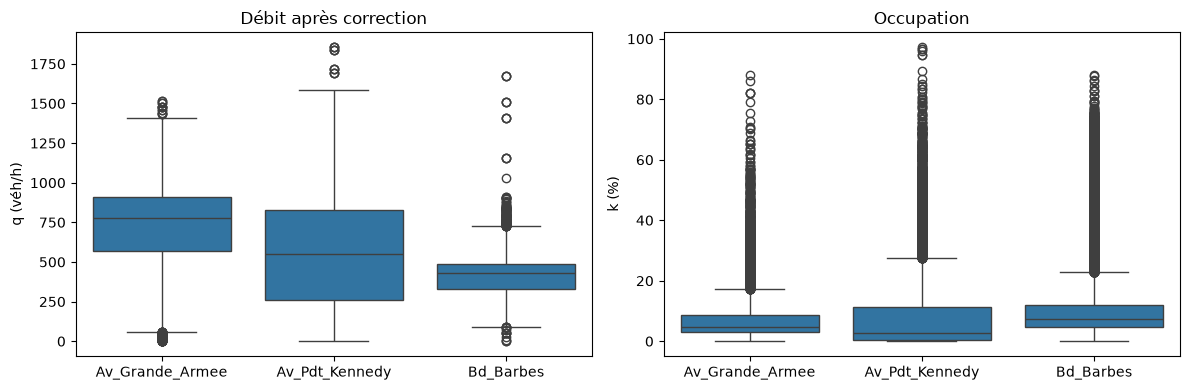

In [14]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="libelle", y="q", ax=axes[0])
axes[0].set(title="Débit après correction", xlabel="", ylabel="q (véh/h)")
sns.boxplot(data=df, x="libelle", y="k", ax=axes[1])
axes[1].set(title="Occupation", xlabel="", ylabel="k (%)")
plt.tight_layout()
plt.show()

## 4. Statistiques par trocon

Je calcule les statistiques sur q_propre (débit après interpolation des trous de 3 h ou moins, sans les 2 aberrations). Les tronçons qui partagent le même débit (groupe_q) ont forcément les mêmes statistiques : je garde le numéro de groupe dans le tableau pour le voir.

In [19]:
stats = (df.groupby(["libelle", "groupe_q", "iu_ac"], observed=True)["q_propre"]
           .agg(moyenne="mean", mediane="median", ecart_type="std",
                minimum="min", maximum="max", n_mesures="count")
           .round(1))
stats

moyenne  mediane  ecart_type  minimum  \
libelle         groupe_q iu_ac                                          
Av_Grande_Armee 9        5257     677.1    734.0       227.6     19.0   
                10       5258     676.7    733.0       227.4     19.0   
                11       5259     783.4    841.8       266.9      0.0   
                12       5260     783.7    842.0       267.1      0.0   
Av_Pdt_Kennedy  6        4521     670.4    708.0       324.6      2.0   
                         4524     670.4    708.0       324.6      2.0   
                7        4522     177.1    174.0       108.4      4.0   
                8        4530     618.4    627.0       295.4      2.0   
                         4532     618.4    627.0       295.4      2.0   
                         6161     618.4    627.0       295.4      2.0   
Bd_Barbes       0        1626     431.8    440.0       152.2     89.0   
                1        1627     414.5    447.0       106.0      0.0   
                2        1628     395.5    419.0       111.8     90.0   
                3        1629     403.7    433.0       102.6    108.0   
                         1631     403.7    433.0       102.6    108.0   
                4        1630     403.0    436.0       126.3     49.0   
                         1632     403.0    436.0       126.3     49.0   
                         1634     403.0    436.0       126.3     49.0   
                         1636     403.0    436.0       126.3     49.0   
                5        1633     393.4    423.0       116.1    103.0   
                         1635     393.4    423.0       116.1    103.0   
                         1637     393.4    423.0       116.1    103.0   

                                maximum  n_mesures  
libelle         groupe_q iu_ac                      
Av_Grande_Armee 9        5257    1198.0       4350  
                10       5258    1198.0       4326  
                11       5259    1518.0       4350  
                12       5260    1518.0       4326  
Av_Pdt_Kennedy  6        4521    1582.0       4299  
                         4524    1582.0       4299  
                7        4522     539.0       4322  
                8        4530    1856.0       4256  
                         4532    1856.0       4256  
                         6161    1856.0       4256  
Bd_Barbes       0        1626    1028.0       4102  
                1        1627     650.0       4102  
                2        1628     678.0       4102  
                3        1629     668.0       4356  
                         1631     668.0       4356  
                4        1630     704.0       4319  
                         1632     704.0       4319  
                         1634     704.0       4319  
                         1636     704.0       4319  
                5        1633    1675.0       4357  
                         1635    1675.0       4357  
                         1637    1675.0       4357

### Par axe, sans compter plusieurs fois la même série
Regardons une seule ligne par série de débit (groupe_q) et par heure, pour que Bd_Barbes ne compte pas 12 fois ce qui n'est que 6 mesures.

In [20]:
series_uniques = df.drop_duplicates(["libelle", "groupe_q", "t_paris"])
par_axe = (series_uniques.groupby("libelle", observed=True)["q_propre"]
             .agg(moyenne="mean", mediane="median", ecart_type="std",
                  minimum="min", maximum="max")
             .round(1))
par_axe

,moyenne,mediane,ecart_type,minimum,maximum
libelle,,,,,
Av_Grande_Armee,730.2,779.0,253.7,0.0,1518.0
Av_Pdt_Kennedy,487.6,396.0,342.2,2.0,1856.0
Bd_Barbes,406.8,433.0,120.8,0.0,1675.0


### Les heures les plus chargées
Pour chaque tronçon, on calcule le débit moyen de chaque heure de la journée, séparément en semaine et le week-end, et on garde les 3 heures les plus chargées.

In [21]:
profil = (df.groupby(["iu_ac", "est_weekend", "heure"])["q_propre"]
            .mean().reset_index())

top3 = (profil.sort_values("q_propre", ascending=False)
              .groupby(["iu_ac", "est_weekend"]).head(3)
              .groupby(["iu_ac", "est_weekend"])["heure"]
              .apply(lambda s: sorted(s.tolist())))

top3 = top3.unstack("est_weekend").rename(columns={False: "semaine", True: "week-end"})
top3.insert(0, "axe", df.drop_duplicates("iu_ac").set_index("iu_ac")["libelle"])
top3.sort_values("axe")

est_weekend,axe,semaine,week-end
iu_ac,,,
5259,Av_Grande_Armee,"[9, 10, 12]","[16, 17, 18]"
5258,Av_Grande_Armee,"[15, 16, 17]","[0, 1, 18]"
5257,Av_Grande_Armee,"[15, 16, 17]","[0, 1, 18]"
5260,Av_Grande_Armee,"[9, 10, 11]","[16, 17, 18]"
6161,Av_Pdt_Kennedy,"[19, 20, 21]","[0, 1, 20]"
4532,Av_Pdt_Kennedy,"[19, 20, 21]","[0, 1, 20]"
4530,Av_Pdt_Kennedy,"[19, 20, 21]","[0, 1, 20]"
4524,Av_Pdt_Kennedy,"[18, 19, 20]","[0, 19, 20]"
4522,Av_Pdt_Kennedy,"[11, 18, 19]","[17, 18, 19]"


**Les résultat** :

Pour le **Débit moyen** , Av_Grande_Armee est l'axe le plus chargé (moyenne 730 véhicules/heure, médiane 779), devant Av_Pdt_Kennedy (488, médiane 396) et Bd_Barbes (407, médiane 433). Sur Av_Pdt_Kennedy la moyenne dépasse la médiane de 92 véhicules/heure et l'écart-type est le plus élevé (342), car les capteurs de cet axe ont des niveaux très différents ; Bd_Barbes est le plus régulier (écart-type 121).
Pour l' **Heures les plus chargées** : en semaine, la pointe est le soir (18 h à 21 h) pour les 6 capteurs d'Av_Pdt_Kennedy et 7 des 12 de Bd_Barbes ; les autres capteurs de Bd_Barbes ont leur pointe le matin (4 capteurs, 8 h à 10 h) ou la nuit (1628). Av_Grande_Armee se distingue : l'après-midi (15 h à 17 h) pour les capteurs 5257 et 5258, le matin (9 h à 12 h) pour 5259 et 5260. Le week-end, 0 h ou 1 h entrent dans le top 3 de 14 capteurs sur 22.
Pour les **Capteurs atypiques et séries partagées** : le capteur 4522 (Av_Pdt_Kennedy) sort du lot avec 177 véhicules/heure en moyenne, contre 618 à 670 pour les autres capteurs de l'axe. Les capteurs d'un même `groupe_q` ont exactement les mêmes statistiques  : les 22 capteurs ne représentent que 13 séries de débit distinctes .



## 5. Sauvegarde et bilan


In [22]:
df.to_parquet("data/processed/comptages_transformes.parquet", index=False)
print(df.shape)
df.columns.tolist()

(97152, 22)


['iu_ac',
 't_paris',
 'libelle',
 'q',
 'k',
 'etat_trafic',
 'groupe_q',
 'q_impute',
 'k_impute',
 'q_comble',
 'k_comble',
 'heure',
 'jour_semaine',
 'est_weekend',
 'mois',
 'congestion',
 'barre_Barré',
 'barre_Invalide',
 'barre_Ouvert',
 'aberrant_iqr',
 'q_aberrant',
 'q_propre']